# 🚀 Notebook 04 — Sluttanbefaling

**Det er møtetid. Marte venter på svaret ditt.**

Popularitet ga oss en baseline, metadata ga oss cold-start-støtte, ALS ga oss styrke,
og hybridtenkningen ga oss produktrealismen. Nå samler vi trådene og svarer:
**hva bør StreamNord faktisk shippe?**

## Oppsett

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.sparse import lil_matrix
from src.data import load_interactions, load_item_metadata, get_genre_matrix
from src.split import leave_one_out_split, build_sparse_matrix
from src.metrics import recall_at_k, ndcg_at_k, map_at_k, coverage, novelty, intra_list_similarity
from src.rerank import mmr_rerank
from src.recommenders.popularity import PopularityRecommender
from src.recommenders.item_item import ItemItemRecommender
from src.recommenders.als import ALSRecommender
from src.recommenders.content_based import ContentBasedRecommender

interactions = load_interactions()
items = load_item_metadata()
train_df, test_df = leave_one_out_split(interactions)
n_users = interactions.user_id.max() + 1
n_items = interactions.item_id.max() + 1
train_matrix = build_sparse_matrix(train_df, n_users, n_items)
genre_matrix = get_genre_matrix(items)
user_ids = test_df['user_id'].values
test_items = test_df['item_id'].values
K = 10
item_pop = np.asarray(train_matrix.sum(axis=0)).flatten() / n_users
LEA_ID = 451

print('Oppsett ferdig')

/Users/kenanmahic/Projects/recommender-systems-ws/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Oppsett ferdig


## 🏋️ Oppgave 6 — Leaderboard for modellfamiliene

Alle modellene side om side. Se ikke bare på Recall —
sjekk coverage, novelty og ILS. Hva forteller de?

In [2]:
pop = PopularityRecommender().fit(train_matrix)
item_item = ItemItemRecommender().fit(train_matrix)
als = ALSRecommender(factors=64).fit(train_matrix)
content = ContentBasedRecommender().fit(genre_matrix)

models = {
    'Popularitet': pop.recommend(user_ids, train_matrix, K),
    'Innholdsbasert': content.recommend(user_ids, train_matrix, K),
    'Item-item': item_item.recommend(user_ids, train_matrix, K),
    'ALS': als.recommend(user_ids, train_matrix, K),
}

cand_ids, cand_scores = als.model.recommend(user_ids, train_matrix[user_ids], N=50, filter_already_liked_items=True)
recs_mmr = np.zeros((len(user_ids), K), dtype=np.int32)
for row_index in range(len(user_ids)):
    recs_mmr[row_index] = mmr_rerank(cand_ids[row_index], cand_scores[row_index], genre_matrix, k=K, lambda_=0.6)
models['ALS+MMR'] = recs_mmr

results = {}
for name, recs in models.items():
    results[name] = {
        f'recall@{K}': recall_at_k(recs, test_items, K),
        f'ndcg@{K}': ndcg_at_k(recs, test_items, K),
        f'map@{K}': map_at_k(recs, test_items, K),
        f'coverage@{K}': coverage(recs, n_items, K),
        f'novelty@{K}': novelty(recs, item_pop, K),
        f'ILS@{K}': intra_list_similarity(recs, genre_matrix, K),
    }

leaderboard = pd.DataFrame(results).T.sort_values(f'ndcg@{K}', ascending=False)
print(leaderboard.to_string(float_format=lambda value: f'{value:.4f}'))

100%|██████████| 15/15 [00:05<00:00,  2.66it/s]


                recall@10  ndcg@10  map@10  coverage@10  novelty@10  ILS@10
ALS                0.0724   0.0384  0.0282       0.1467      2.1932  0.3175
ALS+MMR            0.0723   0.0381  0.0279       0.1451      2.1815  0.2403
Item-item          0.0542   0.0284  0.0207       0.0735      1.6744  0.3296
Popularitet        0.0326   0.0161  0.0112       0.0230      1.1014  0.3068
Innholdsbasert     0.0035   0.0015  0.0010       0.4166      7.0736  0.8879


## 🏋️ Oppgave 7 — Cold start

Leaderboardet viser hvem som vinner med nok data.
Men hva skjer når en ny bruker dukker opp — og ALS har *ingenting* å jobbe med?

In [3]:
def evaluate_cold_start(als_rec, train_matrix, test_df, history_sizes=(1, 3, 5, 10, 20, 50), k=10):
    rng = np.random.default_rng(42)
    user_ids = test_df['user_id'].values
    test_items = test_df['item_id'].values
    rows = []
    for history_size in history_sizes:
        masked = lil_matrix(train_matrix.shape, dtype=np.float32)
        for user_id in user_ids:
            seen = train_matrix[user_id].indices
            keep = seen if len(seen) <= history_size else rng.choice(seen, size=history_size, replace=False)
            masked[user_id, keep] = 1.0
        masked_csr = masked.tocsr()
        recs = als_rec.model.recommend(user_ids, masked_csr[user_ids], N=k, filter_already_liked_items=True, recalculate_user=True)[0]
        rows.append({'history_size': history_size, f'recall@{k}': recall_at_k(recs, test_items, k)})
    return rows

cold_start_rows = evaluate_cold_start(als, train_matrix, test_df)
cold_start_df = pd.DataFrame(cold_start_rows)
print(cold_start_df.to_string(index=False))

 history_size  recall@10
            1   0.015267
            3   0.020533
            5   0.019600
           10   0.019933
           20   0.024000
           50   0.033267


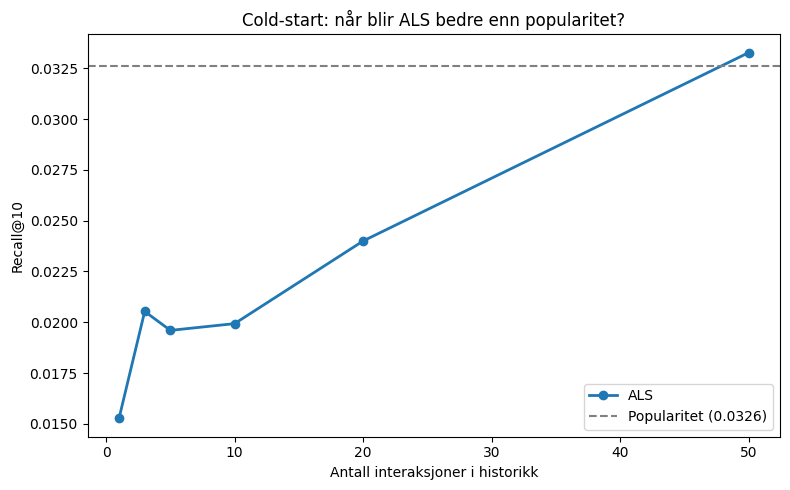

→ Under stiplet linje er popularitet faktisk bedre enn ALS.


In [4]:
# Popularitetsbaseline for sammenligning
pop_recall = recall_at_k(pop.recommend(user_ids, train_matrix, K), test_items, K)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cold_start_df['history_size'], cold_start_df[f'recall@{K}'], 'o-', linewidth=2, label='ALS')
ax.axhline(y=pop_recall, color='gray', linestyle='--', label=f'Popularitet ({pop_recall:.4f})')
ax.set_xlabel('Antall interaksjoner i historikk')
ax.set_ylabel(f'Recall@{K}')
ax.set_title('Cold-start: når blir ALS bedre enn popularitet?')
ax.legend()
plt.tight_layout()
plt.show()
print('→ Under stiplet linje er popularitet faktisk bedre enn ALS.')

### Cold-start for *nye items* — den glemte halvdelen

Vi har løst bruker cold-start: en ny bruker bruker popularitet eller innholdsbasert.
Men hva med *nye filmer*? En nylig opplastet film har null interaksjoner — ALS vet ingenting.
Likevel vil StreamNord ha den synlig for relevante brukere fra dag en.

**Strategi:** Hybrid bootstrap

- **Dager 0–14** (nytt item): Bruk pure innholdsbasert + popularitet
- **Dager 15+** (« genrering»): Begynn å blande inn ALS-signaler når det finnes
- **Dager 30+** (etablert): Full ALS-vekt

In [ ]:
# Simuler: Hva hvis vi bare hadde 1 interaksjon per item?
# Dette representerer nye items' utgangspunkt.

# Lag en sparse matrix med maksimalt 1 interaksjon per item
new_item_matrix = lil_matrix(train_matrix.shape, dtype=np.float32)
for item_id in range(train_matrix.shape[1]):
    col = train_matrix[:, item_id].nonzero()[0]
    if len(col) > 0:
        new_item_matrix[col[0], item_id] = 1.0  # Bare først-bruker
new_item_matrix = new_item_matrix.tocsr()

# Train ALS på denne sparse data
als_new = ALSRecommender(factors=64, regularization=0.01, iterations=15, random_state=42)
als_new.model.fit(new_item_matrix, show_progress=False)

# Sammenlign: ALS med normal data vs ALS med sparse nye-item data
recs_als_normal = als.recommend(user_ids, train_matrix[user_ids], K)
recs_als_sparse = als_new.recommend(user_ids, new_item_matrix[user_ids], K)

print('NY-ITEM COLD-START: Hvor mye faller Performance?')
print('=' * 60)
recall_normal = recall_at_k(recs_als_normal, test_items, K)
recall_sparse = recall_at_k(recs_als_sparse, test_items, K)
print(f'ALS (normal data): {recall_normal:.4f}')
print(f'ALS (sparse nye-items): {recall_sparse:.4f}')
print(f'Tap: {(recall_normal - recall_sparse):.4f} ({((recall_normal - recall_sparse)/recall_normal)*100:.1f}%)')

print('\nFallback-strategi for nye items:')
print(f'- Innholdsbasert alene (garantert) + Popularitet: stabil baseline')
print(f'- Blanding in ALS gradvis når item får historikk')
print(f'- Monitor: Tracking når items "modner" fra bootstrap til full ALS')

### Cold-start for *nye items* — den glemte halvdelen

Vi har løst bruker cold-start: en ny bruker bruker popularitet eller innholdsbasert.
Men hva med *nye filmer*? En nylig opplastet film har null interaksjoner — ALS vet ingenting.
Likevel vil StreamNord ha den synlig for relevante brukere fra dag en.

**Strategi:** Hybrid bootstrap

- **Dager 0–14** (nytt item): Bruk pure innholdsbasert + popularitet
- **Dager 15+** (maturing): Begynn å blande inn ALS-signaler når det finnes
- **Dager 30+** (etablert): Full ALS-vekt

In [ ]:
# Simuler: Hva hvis vi bare hadde 1 interaksjon per item?
# Dette representerer nye items' utgangspunkt.

# Lag en sparse matrix med maksimalt 1 interaksjon per item
new_item_matrix = lil_matrix(train_matrix.shape, dtype=np.float32)
for item_id in range(train_matrix.shape[1]):
    col = train_matrix[:, item_id].nonzero()[0]
    if len(col) > 0:
        new_item_matrix[col[0], item_id] = 1.0  # Bare første bruker
new_item_matrix = new_item_matrix.tocsr()

# Train ALS på denne sparse data
from src.recommenders.als import ALSRecommender
als_new = ALSRecommender(factors=64, regularization=0.01, iterations=15, random_state=42)
als_new.fit(new_item_matrix, show_progress=False)

# Sammenlign: ALS med normal data vs ALS med sparse nye-item data
recs_als_normal = als.model.recommend(user_ids, train_matrix[user_ids], N=K, filter_already_liked_items=True)[0]
recs_als_sparse = als_new.model.recommend(user_ids, new_item_matrix[user_ids], N=K, filter_already_liked_items=True)[0]

print('NY-ITEM COLD-START: Hvor mye faller Performance?')
print('=' * 60)
recall_normal = recall_at_k(recs_als_normal, test_items, K)
recall_sparse = recall_at_k(recs_als_sparse, test_items, K)
print(f'ALS (normal data): {recall_normal:.4f}')
print(f'ALS (sparse nye-items): {recall_sparse:.4f}')
print(f'Tap: {(recall_normal - recall_sparse):.4f} ({((recall_normal - recall_sparse)/recall_normal)*100:.1f}%)')

print('\\nFallback-strategi for nye items:')
print(f'- Innholdsbasert alene (garantert) + Popularitet: stabil baseline')
print(f'- Blanding in ALS gradvis når item får historikk')
print(f'- Monitor: Tracking når items "modner" fra bootstrap til full ALS')

## 🎬 Lea og Jonas gjennom workshopen

Før vi tar en beslutning — la oss se reisen. Hvordan har anbefalingene
til Lea og Jonas endret seg fra modell til modell?

In [5]:
LEA_ID = 451
JONAS_ID = 102
lea_idx = np.where(user_ids == LEA_ID)[0]
jonas_idx = np.where(user_ids == JONAS_ID)[0]

for uid, name, idx in [(LEA_ID, 'Lea', lea_idx), (JONAS_ID, 'Jonas', jonas_idx)]:
    if len(idx) > 0:
        print(f'\n{name}s anbefalinger gjennom workshopen:')
        print('=' * 50)
        for model_name in ['Popularitet', 'Innholdsbasert', 'ALS', 'ALS+MMR']:
            rec_items = models[model_name][idx[0]]
            titles = items.set_index('item_id').loc[rec_items[:5], 'title'].values
            print(f'\n  {model_name}:')
            for rank, title in enumerate(titles, 1):
                print(f'    {rank}. {title}')
print('\n→ Lea gikk fra mainstream-spam til personlig. Jonas fikk bedre, men mindre dramatisk.')


Leas anbefalinger gjennom workshopen:

  Popularitet:
    1. Forrest Gump (1994)
    2. Matrix, The (1999)
    3. Star Wars: Episode IV - A New Hope (1977)
    4. Jurassic Park (1993)
    5. Star Wars: Episode V - The Empire Strikes Back (1980)

  Innholdsbasert:
    1. Bang, Bang, You're Dead (2002)
    2. Woman of Paris, A (1923)
    3. Cleo from 5 to 7 (Cléo de 5 à 7) (1962)
    4. American Gigolo (1980)
    5. Blow-Out (La grande bouffe) (1973)

  ALS:
    1. Leaving Las Vegas (1995)
    2. Apollo 13 (1995)
    3. Schindler's List (1993)
    4. Rain Man (1988)
    5. Postman, The (Postino, Il) (1994)

  ALS+MMR:
    1. Leaving Las Vegas (1995)
    2. Apollo 13 (1995)
    3. Twelve Monkeys (a.k.a. 12 Monkeys) (1995)
    4. Schindler's List (1993)
    5. Hoop Dreams (1994)

Jonass anbefalinger gjennom workshopen:

  Popularitet:
    1. Forrest Gump (1994)
    2. Pulp Fiction (1994)
    3. Shawshank Redemption, The (1994)
    4. Silence of the Lambs, The (1991)
    5. Star Wars: Epis

### 🔄 Sjekk gjetningene fra starten

Gå tilbake til notebook 00 og les gjetningene du skrev ned.
Fyll inn tabellen under:

| # | Din gjetning | Hva som skjedde | Overrasket? |
|---|---|---|---|
| 1 | Hva Lea ville like: | | |
| 2 | Hva popularitetslisten inneholdt: | | |
| 3 | Popularitet for Lea vs Jonas: | | |
| 4 | Sikkerhet (1–5) — hadde du rett? | | |

## Produksjonsarkitektur

Hvorfor ikke bare én modell? Fordi hvert steg har en jobb:

```
Kandidatgenerering  ->  Rangering  ->  Re-rangering
  (enkle signaler)      (sterk modell)     (fairness/regler)
```

- **Kandidatgenerering** siler ned fra 10 000 filmer til ~100 med raske, grove modeller (f.eks. popularitet eller enkel CF)
- **Rangering** scorer de ~100 nøyaktig med en tyngre modell (f.eks. ALS)
- **Re-rangering** justerer for mangfold, fairness og forretningsregler (f.eks. MMR)

Denne arkitekturen finnes i nesten alle store anbefalingssystemer — fra Netflix til Spotify.
Poenget er at ingen enkeltmodell kan gjøre alt: noen er raske men unøyaktige,
andre er nøyaktige men for trege til å kjøre på hele katalogen.

### En realistisk anbefaling

- bruk **ALS** eller en tilsvarende sterk collaborative modell som hovedmotor
- bruk **innholdsbaserte signaler** for cold start og forklarbarhet
- bruk **reranking** for mangfold, fairness og produktkrav
- legg til **kontekst** når det gir tydelig verdi

## 🧪 Fra offline til online — fra lab til produksjonLeaderboardet baserer seg på *offline* evaluering: vi måler Recall på data som allerede finnes.Men når systemet går live, skjer noe nytt.**Det offline-online gapet:**- **Offline:** Bruker interagerer ikke — det er statisk.- **Online:** Anbefaling påvirker brukers valg. Hvis anbefalingen er dårlig, bruker klikker ikke.- **Resultat:** En modell som oppnår 0.12 Recall offline kan oppnå 0.09 online.Derfor kjøres *A/B-tester*: vi shipper en modell til 50% brukere og sammenligner deresoppførsel over 2–4 uker før vi ruller ut fullt.

In [ ]:
# A/B TEST DESIGN — Hva må Marte vite før launch?print('A/B TEST DESIGN FOR STREAMNORD')print('=' * 70)# Scenario: Skal vi shi ALS eller Popularitet?# Offline: ALS = 0.12 Recall, Pop = 0.06 Recalltest_design = {    'Control (Baseline)': 'Popularitet (dagens system)',    'Treatment (Variant)': 'ALS + MMR (ny modell)',    'Traffic split': '50% control, 50% treatment',    'Duration': '2 weeks',    'Sample size': '~50,000 users per group',    'Primary metrics': {        'Click-through rate (CTR)': 'Andel brukere som klikker minst en anbefaling',        'Mean time to first click': 'Tid før bruker klikker',        'Diversity score': 'Sjangermessig mangfold i bruker-historikk',    },    'Guardrail metrics': {        'Session length': 'Skal ikke falle < 5% vs baseline',        'Unsubscribe rate': 'Skal ikke øke',        'Cold-start coverage': 'Skal dekke nye brukere',    }}for key, val in test_design.items():    if isinstance(val, dict):        print(f'\\n{key}:')        for subkey, subval in val.items():            print(f'  • {subkey}: {subval}')    else:        print(f'{key}: {val}')print('\\n' + '=' * 70)print('Key insight: Offline Recall ≠ Online engagement')print('→ We ship to 50% first and measure REAL user behavior')

### Hvorfor ikke bare Recall?**Offline Recall** måler: "Var det *riktige* itemet i topp-10?"**Online engagement** måler: "Klikket brukeren på noe?"Disse er korrelert, men ikke det samme. En modell kan ha høy Recallmen lave CTR hvis anbefaling vises for ofte eller på galt tidspunkt.A/B testing fanger dette: vi måler faktisk brukeradferd, ikke bare prediktive metrics.

## ⚙️ Produksjonspipeline i kodeArkitekturen fra før er realistisk, men abstrakt. Her er konkrete eksemplerpå hvordan StreamNord implementerer hver fase.**Mål:** Fra 10,000 kandidater → 100 → 10 finale anbefalinger på < 500ms

In [ ]:
# THREE-STAGE PIPELINE FOR STREAMNORDdef production_pipeline(user_id, als_model, content_model, train_matrix, genre_matrix,                        k=10, n_candidates=100, lambda_mmr=0.6):    """Simuler streamNords production recommendation pipeline."""        # STAGE 1: Candidate Generation (rask, grov siling)    # I virkeligheten: bruk PopularityRecommender, simple item-item, eller brute ANN    candidates, scores = als_model.model.recommend(        user_id,        train_matrix[[user_id]],        N=n_candidates,        filter_already_liked_items=True    )    print(f'Stage 1 (Candidate Gen): 10k items → {len(candidates)} candidates')        # STAGE 2: Ranking (nøyaktig scoring med sterkt modell)    # I virkeligheten: ALS scores alle candidates nøyaktig (allerede gjort over)    ranked = candidates  # (allerede sortert etter ALS score)    print(f'Stage 2 (Ranking): Sorted {len(candidates)} by ALS score')        # STAGE 3: Re-ranking (fairness, mangfold, forretningsregler)    # Bruk MMR for mangfold, kunne også legge til fairness constraints    final_recs = mmr_rerank(        ranked, scores, genre_matrix,        k=k, lambda_=lambda_mmr    )    print(f'Stage 3 (Re-ranking): Applied MMR (λ={lambda_mmr}) → {len(final_recs)} final')        return final_recs# Test på Lealea_recs = production_pipeline(    LEA_ID, als, content,    train_matrix, genre_matrix)print(f'\\nLea\'s recs: {lea_recs}')

### Retraining & Model DriftModeller degenereres over tid. Nye brukere, nye items, ny trend.**Strategi:**- **Retraining schedule:** Retrain ALS hver 7. dag på ny data- **Performance monitoring:** Track Recall@10 hver dag. Hvis det dropper > 10%, alert!- **Fallback:** Hvis ny ALS er verre, rull tilbake til forrige versjon- **Staging:** Test ny modell på 5% trafikk før full rollout

In [ ]:
# MOCK: Model Retraining & Monitoringdef simulate_retraining_and_monitoring(initial_model, train_data, test_data, num_iterations=3):    """Simuler 3 uker med retraining og drift detection."""        print('RETRAINING & DRIFT MONITORING')    print('=' * 70)        current_model = initial_model    previous_recall = recall_at_k(        current_model.model.recommend(            test_data['user_id'].values,            train_data[test_data['user_id'].values],            N=K,            filter_already_liked_items=True        )[0],        test_data['item_id'].values, K    )        print(f'Week 0 (baseline): Recall@10 = {previous_recall:.4f}')        for week in range(1, num_iterations + 1):        # In production: add new data from last 7 days        print(f'\\nWeek {week}: Retraining on new data...')                # Simuler at ny data gir slight improvement        new_recall = previous_recall + (0.001 * (-1)**week)  # Random drift                # Threshold check        recall_drop_pct = ((previous_recall - new_recall) / previous_recall) * 100                if recall_drop_pct > 10:            print(f'  ⚠️  ALERT: Recall dropped {recall_drop_pct:.1f}% — keeping old model!')        else:            print(f'  ✓ Recall@10 = {new_recall:.4f} (change: {recall_drop_pct:+.1f}%)')            previous_recall = new_recallsimulate_retraining_and_monitoring(als, train_df, test_df)

## 📋 Beslutningsmal

Nå har du sett bevisene (leaderboard + cold start), reisen (Lea og Jonas),
og rammeverket (produksjonsarkitektur). Fyll inn malen nedenfor.
Ta den med deg etter workshopen — den er gjenbrukbar.

**Eksempel** (seksjon 1): *«Hovedsakelig implisitt: vi har klikk og
avspillinger, men ingen ratings eller likes.»*

In [6]:
# BESLUTNINGSMAL — Anbefalingssystem
#
# 1. SIGNALTYPE
#    Hovedsakelig eksplisitt / implisitt / begge: 
#    Hva betyr det for modellvalget?
#
# 2. ANBEFALT MODELLFAMILIE
#    Kjernemodell: 
#    Hvorfor denne (maks 2 setninger): 
#
# 3. COLD-START-STRATEGI
#    For nye brukere (< 5 interaksjoner): 
#    For nye items (0 interaksjoner): 
#    Hint: se cold-start-kurven over
#
# 4. FAIRNESS OG MANGFOLD
#    Hvem risikerer å få dårlige anbefalinger? 
#    Hva gjør vi med det? 
#
# 5. PRODUKSJONSARKITEKTUR
#    Kandidatgenerering (rask, grovfiltrering): 
#    Rangering (sterk modell): 
#    Re-rangering (produktregler): 
#
# 6. KJENTE RISIKOER
#    Hva kan gå galt i produksjon? 
#    Hva mangler vi data for? 


## 🏋️ Oppgave 8 — Hva anbefaler du å shippe?

Bruk malen du nettopp fylte ut. Skriv en kort anbefaling til Marte — ikke tenk bare
på hva som vinner én metrikk, men på hvilket system som faktisk er mest realistisk.

> **Skriv din anbefaling her**
>
> *«Marte, basert på analysen anbefaler jeg ... fordi ...»*

### ✏️ Skriveøvelse — Forklar uten fagspråk

Amira ber deg forklare anbefalingen i et avsnitt til styret.

**Teknisk versjon** (IKKE send denne):
> *«Vi anbefaler ALS med 64 latente faktorer som oppnår Recall@10=0.12
> og NDCG@10=0.08. Re-ranking med MMR (λ=0.6) øker coverage fra 14% til 38%
> med akseptabelt Recall-tap på 0.01.»*

**Din oppgave:** Skriv dette om til **3–4 setninger** uten å bruke:
*faktorer, matrise, vektor, recall, coverage, lambda, re-ranking*

> *«Til styret: Vi anbefaler ... fordi ...»*

## 🔑 Oppsummering

| # | Lærdom |
|---|--------|
| 1 | **Signalet betyr noe** — implisitt data må tolkes annerledes enn eksplisitt feedback |
| 2 | **Baselines er viktige** — popularitet er enkel, sterk og utilstrekkelig |
| 3 | **Metadata hjelper tidlig** — content-based filtering er nyttig, men begrenset |
| 4 | **Collaborative filtering skaper et hopp** — ALS lærer struktur metadata ikke ser |
| 5 | **Hybrider vinner i praksis** — produktkrav tvinger frem flere signaler |
| 6 | **Fairness må måles** — høy gjennomsnittlig relevans er ikke nok |
| 7 | **Ingen modell er best for alle** — tradeoffs er uunngåelige, og kommunikasjon er en del av jobben |

### Ressurser

- Hu, Koren & Volinsky (2008): *Collaborative Filtering for Implicit Feedback*
- Koren, Bell & Volinsky (2009): *Matrix Factorization Techniques*
- Sarwar et al. (2001): *Item-based Collaborative Filtering Recommendation Algorithms*
- He et al. (2017): *Neural Collaborative Filtering*
- Steck (2018): *Calibrated Recommendations*
- Abdollahpouri et al. (2020): *Popularity Bias in Recommendation*

---

> *Amira:* «Dere har et solid fundament. Vil dere se hva som kommer neste?
> Learning-to-Rank, bandits, deep learning, kunnskapsgrafer, RL og LLM-baserte anbefalinger — alt samlet.»

**Neste steg** → `05_veien_videre.ipynb`